Name: Harshavardan Patil


Bits Email ID: 2025ac05711@wilp.bits-pilani.ac.in


Assignment 2


In [72]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [73]:
#import necessary libraries for model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [74]:
# import necessary libraries for model training and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [75]:
#import necessary libraries for model evaluation metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,matthews_corrcoef)

In [76]:
# Load the dataset
df = pd.read_csv("HR.csv")
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,80,0,8,0,1,6,4,0,5,1
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,80,1,10,3,3,10,7,1,7,0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,80,0,7,3,3,0,0,0,0,1
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,80,0,8,3,3,8,7,3,0,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,80,1,6,3,3,2,2,2,2,0


In [77]:
#Examine dataset size, missing values, and feature types. 
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1470, 35)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   BusinessTravel            1470 non-null   str  
 2   DailyRate                 1470 non-null   int64
 3   Department                1470 non-null   str  
 4   DistanceFromHome          1470 non-null   int64
 5   Education                 1470 non-null   int64
 6   EducationField            1470 non-null   str  
 7   EmployeeCount             1470 non-null   int64
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   str  
 11  HourlyRate                1470 non-null   int64
 12  JobInvolvement            1470 non-null   int64
 13  JobLevel                  1470 non-null   int64
 14  JobRole                   

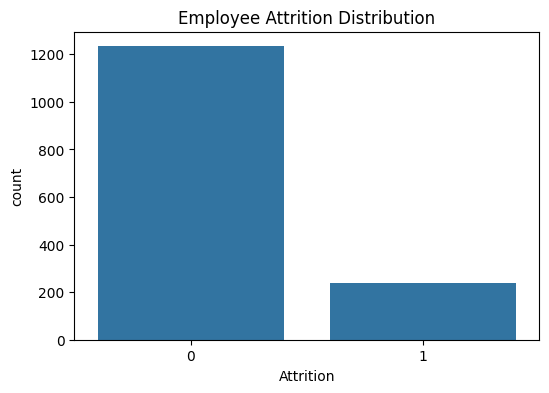

In [78]:
# Check for class imbalance in the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

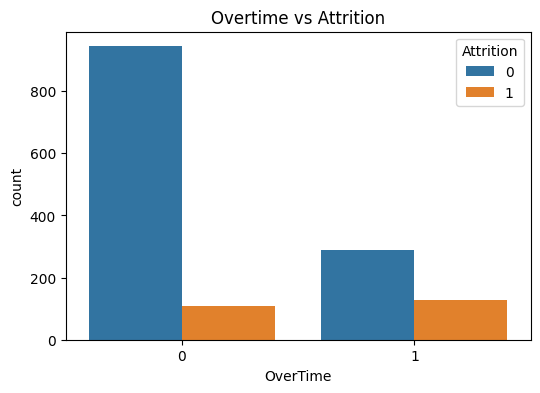

In [79]:
# Check for class imbalance in the 'OverTime' feature
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Overtime vs Attrition')
plt.show()

Employees working overtime exhibit a higher attrition tendency compared to employees who do not work overtime.

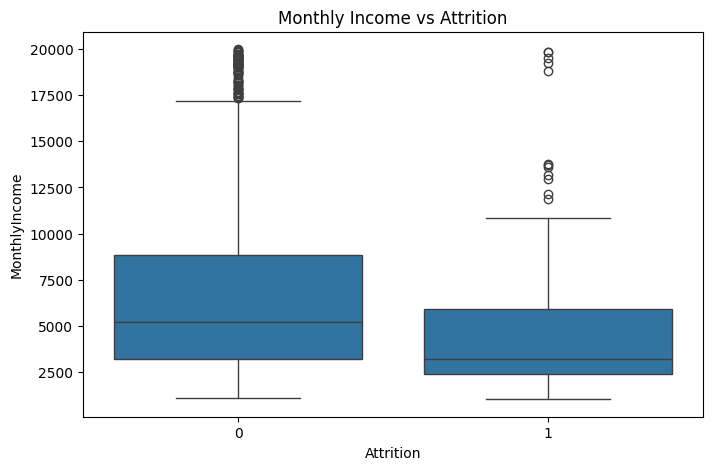

In [80]:
# Check for class imbalance in the 'JobRole' feature
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition',
            y='MonthlyIncome',
            data=df)

plt.title('Monthly Income vs Attrition')
plt.show()

Employees with lower monthly income generally show a higher likelihood of attrition compared to employees with higher income levels.

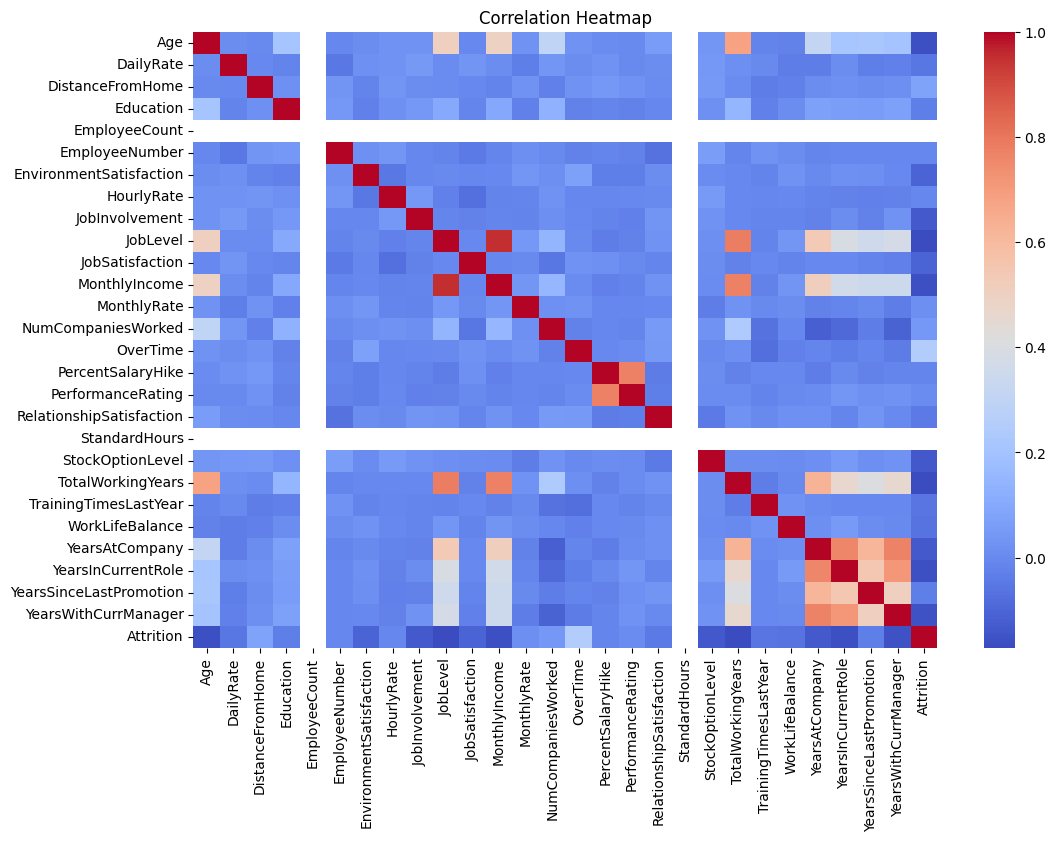

In [81]:
# Check for correlation between features
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [82]:
# ==========================
# Encode Target
# ==========================

df['Attrition'] = df['Attrition'].astype(int)

# ==========================
# Encode Categorical Columns
# ==========================

label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

joblib.dump(label_encoders, "label_encoders.pkl")
# ==========================
# Features and Target
# ==========================

X = df.drop('Attrition', axis=1)
y = df['Attrition']

# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


C:\Users\TXDECSN\AppData\Local\Temp\ipykernel_10748\2945855498.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [83]:
# 
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature  Importance
17             MonthlyIncome    0.073865
0                        Age    0.063968
27         TotalWorkingYears    0.057061
2                  DailyRate    0.054537
11                HourlyRate    0.047466
18               MonthlyRate    0.046718
4           DistanceFromHome    0.046369
8             EmployeeNumber    0.045079
21                  OverTime    0.039857
30            YearsAtCompany    0.039158
33      YearsWithCurrManager    0.035728
19        NumCompaniesWorked    0.034432
22         PercentSalaryHike    0.033211
14                   JobRole    0.032614
31        YearsInCurrentRole    0.027427
9    EnvironmentSatisfaction    0.027134
29           WorkLifeBalance    0.026124
15           JobSatisfaction    0.025831
12            JobInvolvement    0.024912
24  RelationshipSatisfaction    0.024276
28     TrainingTimesLastYear    0.024044
26          StockOptionLevel    0.023944
32   YearsSinceLastPromotion    0.023361
6             Ed

Feature importance analysis using Random Forest was performed. Monthly Income, Age, Total Working Years, Daily Rate, Overtime, Years at Company, and Years with Current Manager emerged as the most influential predictors of employee attrition. EmployeeCount, StandardHours, Over18, and EmployeeNumber were removed because they were either constant-valued attributes or identifier fields that do not contribute meaningful predictive information. All other features were retained for model training and evaluation.

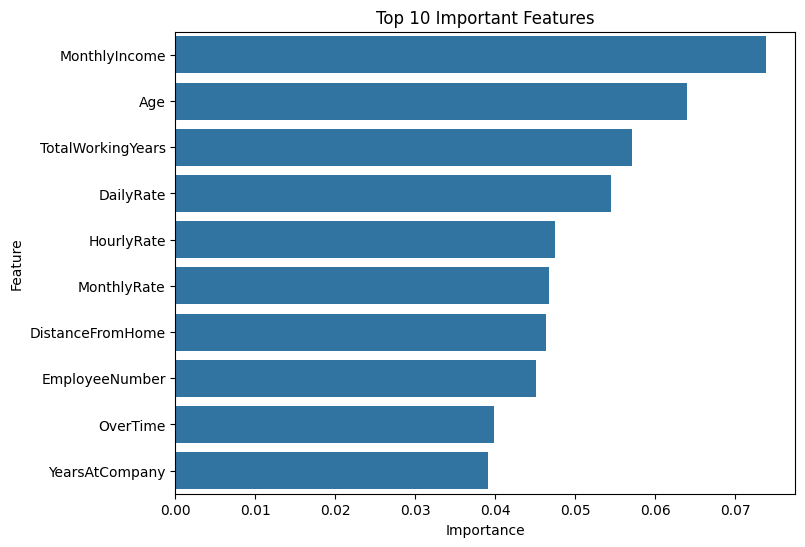

In [84]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title("Top 10 Important Features")
plt.show()

In [85]:
# ==========================
# Remove columns with no value
# ==========================

cols_to_drop = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df.drop(columns=cols_to_drop, inplace=True)

In [86]:
## Recreate X and Y split again after dropping columns
# ==========================
# Features and Target
# ==========================

X = df.drop('Attrition', axis=1)
y = df['Attrition']

# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [87]:
# ==========================
# Save Test Data
# ==========================

test_data = X_test.copy()
test_data['Attrition'] = y_test

test_data.to_csv("test_data.csv", index=False)

print("test_data.csv saved")

test_data.csv saved


In [88]:
# ==========================
# Scale Data
# ==========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [89]:
# ==========================
# Models
# ==========================

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=2000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes":
        GaussianNB(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

In [90]:

# ==========================
# Train and Evaluate
# ==========================
results = []
for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    else:
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append([
        name,
        accuracy,
        auc,
        precision,
        recall,
        f1,
        mcc
    ])

    file_name = name.lower().replace(" ", "_")
    joblib.dump(model, f"{file_name}.pkl")

In [91]:
# ==========================
# Results Table
# ==========================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1",
        "MCC"
    ]
)

print("\nModel Performance\n")
print(results_df)

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("\nmodel_comparison.csv saved")


Model Performance

                 Model  Accuracy       AUC  Precision    Recall        F1  \
0  Logistic Regression  0.874150  0.805668   0.692308  0.382979  0.493151   
1        Decision Tree  0.782313  0.594797   0.319149  0.319149  0.319149   
2                  KNN  0.853741  0.677965   0.666667  0.170213  0.271186   
3          Naive Bayes  0.748299  0.744078   0.348315  0.659574  0.455882   
4        Random Forest  0.843537  0.789043   0.545455  0.127660  0.206897   

        MCC  
0  0.452525  
1  0.189594  
2  0.285269  
3  0.338817  
4  0.207434  

model_comparison.csv saved


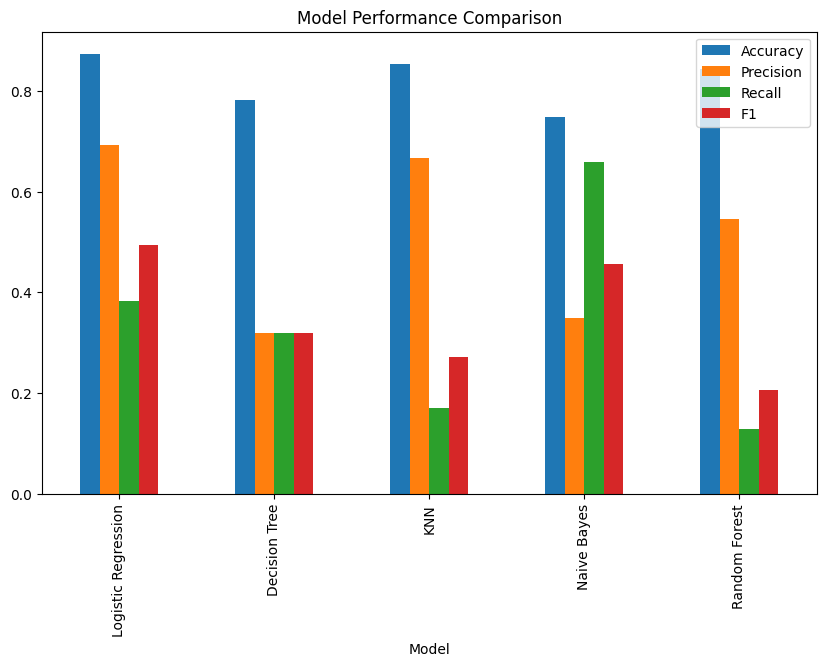

In [92]:
# Model Performance Comparison plot
results_df.set_index('Model')[
    ['Accuracy','Precision','Recall','F1']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.show()

This study developed multiple machine learning models to predict employee attrition using HR analytics data. After preprocessing, feature selection, and model evaluation, Logistic Regression achieved the best overall performance with an accuracy of 87.4%. Feature importance analysis highlighted MonthlyIncome, Age, TotalWorkingYears, OverTime, and YearsAtCompany as significant factors influencing employee attrition. The developed model can assist organizations in identifying employees at risk of leaving and support proactive retention strategies.